# VGGT MRI Visualization

This notebook verifies the input slices and runs VGGT inference using either the pre-trained weights or your fine-tuned local checkpoint.

In [1]:
import os
import ssl
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import functional as F
import cv2
import nibabel as nib
import sys

# 1. Environment Setup
ssl._create_default_https_context = ssl._create_unverified_context
os.environ["TORCH_HOME"] = "./scratch/torch_cache"
os.environ["HF_HOME"] = "./scratch/hf_cache"

sys.path.append(os.path.abspath("training"))

from vggt.models.vggt import VGGT
from demo_viser import viser_wrapper
from vggt.utils.pose_enc import pose_encoding_to_extri_intri

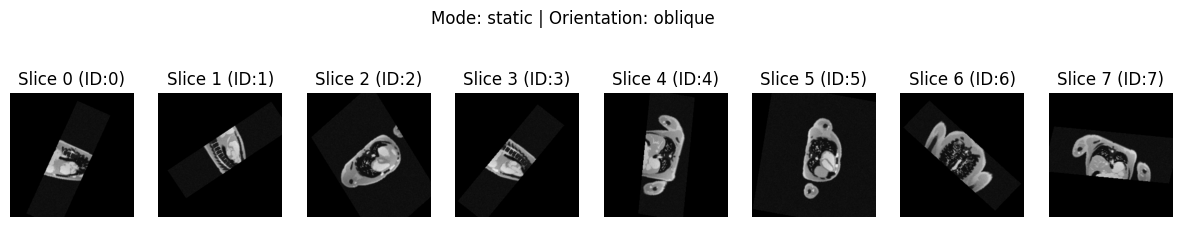

In [2]:
from data.datasets.mri_dataset import MRIDataset
from omegaconf import OmegaConf

DATA_DIR = "/home/minsukc/vggt/scratch/nifti/cardiac_1sec_10phase/nifti/card_3.125x3.125x3.125mm_256x256x70x10x4_snr20_fa60_bh"
num_slices = 8
target_size = 518

# --- CONFIGURATION ---
MODE = "static"  # "static" or "dynamic"
MRI_MODE = "oblique"  # "axial", "mixed", "oblique"

common_conf = OmegaConf.create(
    {
        "img_size": target_size,
        "patch_size": 14,
        "augs": {"scales": [1.0, 1.0], "cojitter": False, "cojitter_ratio": 0.5, "color_jitter": None, "gray_scale": False, "gau_blur": False},
        "rescale": True,
        "rescale_aug": False,
        "landscape_check": False,
        "load_track": False,
        "track_num": 0,
        "training": False,
        "inside_random": False,
        "allow_duplicate_img": False,
        "debug": False,
        "get_nearby": False,
        "load_depth": False,
    }
)

dataset = MRIDataset(common_conf=common_conf, data_root=DATA_DIR, mode=MODE, mri_mode=MRI_MODE, num_slices=num_slices)
data = dataset.get_data(seq_index=0)

images_list = [torch.from_numpy(img).permute(2, 0, 1) / 255.0 for img in data["images"]]
images_tensor = torch.stack(images_list).unsqueeze(0)

fig, axes = plt.subplots(1, num_slices, figsize=(15, 3))
for i in range(num_slices):
    axes[i].imshow(images_tensor[0, i].permute(1, 2, 0).numpy())
    axes[i].axis("off")
    axes[i].set_title(f"Slice {i} (ID:{data['ids'][i]})")
plt.suptitle(f"Mode: {MODE} | Orientation: {MRI_MODE}")
plt.show()

In [3]:
device = "cuda"
model = VGGT()

use_pretrained = False  # Set to False to load from local checkpoint

# Update this path to your latest experiment folder
# Example: './scratch/logs/mri_finetune_full_2026-02-26_13-00-00/ckpts/checkpoint.pt'
# ckpt_path = "./scratch/logs/mri_finetune_full/ckpts/checkpoint.pt"
# ckpt_path = "/home/minsukc/vggt/scratch/logs/mri_finetune_2026-02-26_14-16-35/ckpts/checkpoint.pt"
ckpt_path = "/home/minsukc/vggt/scratch/logs/mri_finetune_226992337_2026-03-08_18-07-43/ckpts/checkpoint.pt"

if os.path.exists(ckpt_path) and not use_pretrained:
    print(f"Loading local checkpoint: {ckpt_path}")
    checkpoint = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(checkpoint["model"], strict=False)
else:
    print("Local checkpoint not found. Loading official weights...")
    _URL = "https://huggingface.co/facebook/VGGT-1B/resolve/main/model.pt"
    model.load_state_dict(torch.hub.load_state_dict_from_url(_URL, model_dir="./scratch/torch_cache"))

model.eval().to(device)

with torch.no_grad():
    with torch.cuda.amp.autocast(dtype=torch.bfloat16):
        predictions = model(images_tensor.to(device), batch={k: v.to(device) for k, v in batch.items() if isinstance(v, torch.Tensor)})

print("Inference Done.")

Loading local checkpoint: /home/minsukc/vggt/scratch/logs/mri_finetune_226992337_2026-03-08_18-07-43/ckpts/checkpoint.pt
Inference Done.


In [4]:
extrinsic, intrinsic = pose_encoding_to_extri_intri(predictions["pose_enc"], (518, 518))
predictions["extrinsic"] = extrinsic
predictions["intrinsic"] = intrinsic

for key in list(predictions.keys()):
    if isinstance(predictions[key], torch.Tensor):
        predictions[key] = predictions[key].cpu().numpy().squeeze(0)

predictions["images"] = images_tensor.cpu().numpy().squeeze(0)

print("Starting Viser with use_point_map=True (Required for Point Head fine-tuning)")
viser_server = viser_wrapper(predictions, port=8080, background_mode=True, use_point_map=True)

Starting Viser with use_point_map=True (Required for Point Head fine-tuning)
Starting viser server on port 8080


╭──────────────── viser ────────────────╮
│             ╷                         │
│   HTTP      │ http://localhost:8080   │
│   Websocket │ ws://localhost:8080     │
│             ╵                         │
╰───────────────────────────────────────╯

  0%|          | 0/8 [00:00<?, ?it/s]

Starting viser server...


(viser) Connection opened (0, 1 total), 68 persistent messages

Threshold absolute value: 1.8299692869186401, percentage: 48.2%
Threshold absolute value: 1.220447301864624, percentage: 40.7%
Threshold absolute value: 1.0, percentage: 1.1%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 0.0%
Threshold absolute value: 1.0, percentage: 4.9%
Threshold absolute value: 1.0000001192092896, percentage: 20.9%
Threshold absolute value: 1.0633574724197388, percentage: 36.0%
Threshold absolute value: 1.0633574724197388, percentage: 36.0%
Threshold absolute value: 1.0633574724197388, percentage: 36.0%
Threshold absolute value: 1.0633574724197388, percentage: 36.0%
Threshold absolute value: 1.0633574724197388, percentage: 36.0%Threshold absolute value: 1.0633574724197388, percentage: 

(viser) Connection closed (0, 0 total)